In [1]:
import gc
import os
import time
import statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import make_interp_spline
from memory_profiler import memory_usage
from agtools.core.unitig_graph import UnitigGraph

# Profiling code

In [2]:
# Replace this with your actual function
def my_function(file_path):
    # Placeholder logic
    return UnitigGraph.from_gfa(file_path)

# GFA Line Count
def grep_count(line_prefix, file_path):
    if not os.path.exists(file_path):
        return 0
    with open(file_path, 'r') as f:
        return sum(1 for line in f if line.startswith(line_prefix))

# Get file size in MB
def get_file_size(path):
    if os.path.exists(path):
        return os.path.getsize(path) / (1024 * 1024)  # Convert to MB
    return 0.0

In [3]:
def profile_get_unitig_graph(graph_file):
    start = time.perf_counter()
    
    mem_trace, _ = memory_usage(
        (UnitigGraph.from_gfa, (graph_file,)),
        retval=True,
        interval=0.01,
        timeout=None
    )
    
    end = time.perf_counter()
    
    elapsed = end - start
    peak_mem = max(mem_trace) - min(mem_trace)
    
    return elapsed, peak_mem

def profile_folder(file_path, runs=10):
    graph_file = file_path

    times = []
    peak_mems = []

    for _ in range(runs):
        elapsed, peak = profile_get_unitig_graph(file_path)
        times.append(elapsed)
        peak_mems.append(peak)

    # GFA line stats
    count_S = grep_count("S", file_path)
    count_L = grep_count("L", file_path)
    count_P = grep_count("P", file_path)

    # File sizes in MB
    size_graph = get_file_size(file_path)

    return {
        "folder": file_path,
        "time_min": min(times),
        "time_max": max(times),
        "time_mean": statistics.mean(times),
        "time_std": statistics.stdev(times),
        "peak_mem_min": min(peak_mems),
        "peak_mem_max": max(peak_mems),
        "peak_mem_mean": statistics.mean(peak_mems),
        "peak_mem_std": statistics.stdev(peak_mems),
        "gfa_S": count_S,
        "gfa_L": count_L,
        "gfa_P": count_P,
        "size_graph_MB": size_graph,
    }

def batch_profile(files, runs=10):
    results = []
    
    for file in files:
        
        print(f"Profiling: {file}")
        
        stats = profile_folder(file, runs)
        results.append(stats)
        
        # Manually trigger garbage collection
        gc.collect()
        
    return pd.DataFrame(results)

# Profile unitig graph data

In [11]:
files_list = [
    # "data/SPAdes/ERR2752151/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR2752163/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR2752162/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR2752160/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR2752150/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR2752154/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR2752153/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR594355/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR599362/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR594375/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR594362/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR594361/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR2750828/assembly_graph_after_simplification.gfa",
    # "data/SPAdes/ERR599357/assembly_graph_after_simplification.gfa",
    "data/SPAdes/ERR2750826/assembly_graph_after_simplification.gfa",
    "data/SPAdes/ERR594360/assembly_graph_after_simplification.gfa",
    "data/SPAdes/ERR599383/assembly_graph_after_simplification.gfa",
    "data/SPAdes/ERR599370/assembly_graph_after_simplification.gfa",
    "data/SPAdes/ERR321017/assembly_graph_after_simplification.gfa",
    "data/SPAdes/ERR321018/assembly_graph_after_simplification.gfa",
]

# Run profiling
df_results = batch_profile(files_list, runs=10)

Profiling: data/SPAdes/ERR2750826/assembly_graph_after_simplification.gfa
Profiling: data/SPAdes/ERR594360/assembly_graph_after_simplification.gfa
Profiling: data/SPAdes/ERR599383/assembly_graph_after_simplification.gfa
Profiling: data/SPAdes/ERR599370/assembly_graph_after_simplification.gfa
Profiling: data/SPAdes/ERR321017/assembly_graph_after_simplification.gfa
Profiling: data/SPAdes/ERR321018/assembly_graph_after_simplification.gfa


In [12]:
# Show results
df_results

,folder,time_min,time_max,time_mean,time_std,peak_mem_min,peak_mem_max,peak_mem_mean,peak_mem_std,gfa_S,gfa_L,gfa_P,size_graph_MB
0,data/SPAdes/ERR2750826/assembly_graph_after_si...,14.805084,15.216062,14.985319,0.122691,847.03125,1114.734375,901.064062,79.309000,964142,688708,0,294.070764
1,data/SPAdes/ERR594360/assembly_graph_after_sim...,6.201061,6.355527,6.289870,0.039301,141.00000,171.312500,152.135938,9.187152,482962,129158,0,230.837200
2,data/SPAdes/ERR599383/assembly_graph_after_sim...,5.517546,5.809562,5.602741,0.078955,80.00000,106.671875,89.967187,7.894729,440162,92296,0,183.899756
3,data/SPAdes/ERR599370/assembly_graph_after_sim...,7.354276,7.645486,7.529502,0.093198,334.00000,358.921875,344.292188,7.715847,499495,328229,0,163.461231
4,data/SPAdes/ERR321017/assembly_graph_after_sim...,2.717938,2.859176,2.809416,0.045126,106.00000,138.718750,118.871875,11.243096,145829,197397,0,40.947277
5,data/SPAdes/ERR321018/assembly_graph_after_sim...,1.864252,1.973039,1.919329,0.037431,19.00000,45.296875,29.229688,8.021226,96998,133965,0,24.522568


In [13]:
# Save to CSV
df_results.to_csv("data/profiling_unitig_graphs.csv", index=False)

# Plot

In [2]:
# Read the profiling results from CSV file
df_results = pd.read_csv("data/profiling_unitig_graphs.csv")

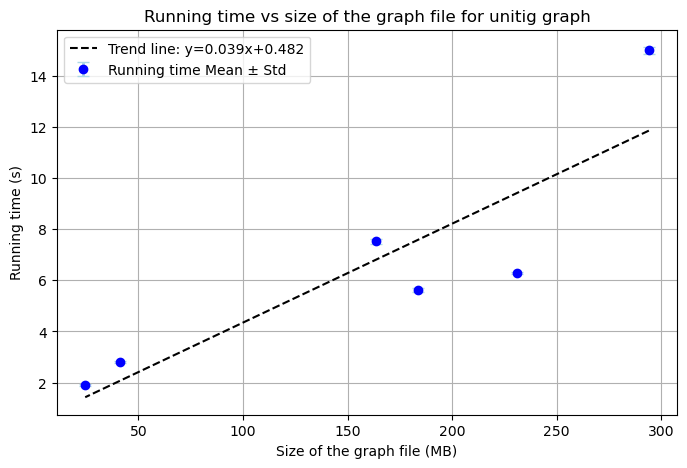

In [8]:
# Example data from df_results
x = df_results["size_graph_MB"].to_numpy()
y = df_results["time_mean"].to_numpy()
yerr = df_results["time_std"].to_numpy()

# Fit a simple linear regression for the trend line
m, b = np.polyfit(x, y, 1)  # slope, intercept
trend_y = m * x + b

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=yerr, fmt='o', color='blue',
             ecolor='lightblue', elinewidth=2, capsize=4,
             label='Running time Mean ± Std')

# Plot trend line
plt.plot(x, trend_y, '--', color='black', label=f'Trend line: y={m:.3f}x+{b:.3f}')

plt.xlabel("Size of the graph file (MB)")
plt.ylabel("Running time (s)")
plt.title("Running time vs size of the graph file for unitig graph")
plt.legend()
plt.grid(True)

# Save to file
plt.savefig("unitig_time.png", dpi=300, bbox_inches='tight')
plt.show()

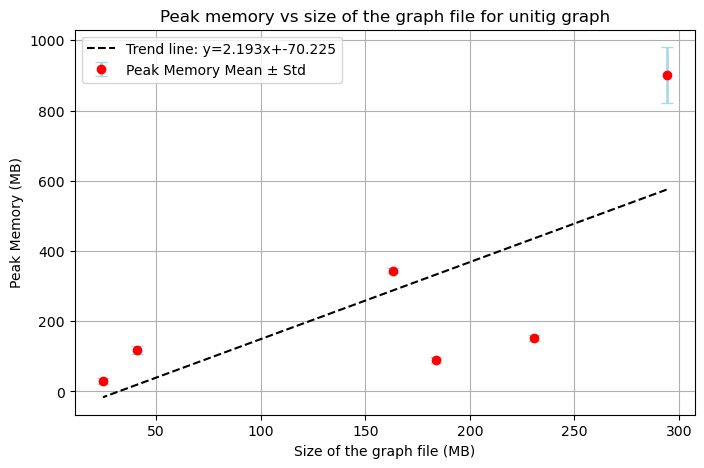

In [7]:
# Plot Peak Memory Mean with error bars
x = df_results["size_graph_MB"]
y = df_results["peak_mem_mean"]
yerr = df_results["peak_mem_std"]

# Fit a simple linear regression for the trend line
m, b = np.polyfit(x, y, 1)  # slope, intercept
trend_y = m * x + b

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=yerr, fmt='o', color='red',
             ecolor='lightblue', elinewidth=2, capsize=4,
             label='Peak Memory Mean ± Std')

# Plot trend line
plt.plot(x, trend_y, '--', color='black', label=f'Trend line: y={m:.3f}x+{b:.3f}')

plt.xlabel("Size of the graph file (MB)")
plt.ylabel("Peak Memory (MB)")
plt.title("Peak memory vs size of the graph file for unitig graph")
plt.legend()
plt.grid(True)

# Save to file
plt.savefig("unitig_mem.png", dpi=300, bbox_inches='tight')
plt.show()